# Toffoli Gate (CCX) â€” Universal Reversible Computing
**Notebook:** Verification of the 3-qubit Toffoli gate and its use in reversible arithmetic

## Overview

The **Toffoli gate** (also called CCX or CCNOT) is a 3-qubit gate:
- 2 **control** qubits and 1 **target** qubit
- Flips the target if and only if **both** controls are $|1\rangle$

$$\text{Toffoli}|c_1, c_2, t\rangle = |c_1, c_2, t \oplus (c_1 \cdot c_2)\rangle$$

### Why it matters
- **Universal for reversible classical computing** â€” any classical logic circuit can be
  built from Toffoli gates (AND, NOT, fanout)
- **Universal for quantum computing** combined with Hadamard
- Used in quantum arithmetic (adders, multipliers) and error correction

### Truth table
| $c_1$ | $c_2$ | $t_{in}$ | $t_{out}$ |
|-------|-------|----------|-----------|
| 0 | 0 | 0 | 0 |
| 0 | 0 | 1 | 1 |
| 0 | 1 | 0 | 0 |
| 0 | 1 | 1 | 1 |
| 1 | 1 | 0 | **1** |
| 1 | 1 | 1 | **0** |

The gate is its own inverse: applying it twice returns to the original state.

### Reversibility and uncomputation
Quantum gates must be **reversible** (unitary). The Toffoli gate achieves classical AND
reversibly by keeping the inputs intact and writing the result to an ancilla qubit.
Uncomputation restores ancilla qubits to $|0\rangle$ after use.

## Testing CCNOT (Toffoli) gate using IBMQ

#### Load libraries

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

# pip install qiskit qiskit-aer qiskit-ibm-runtime
import qiskit as qk
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from math import pi
from qiskit.visualization import plot_bloch_vector
from qiskit.visualization import plot_bloch_multivector, plot_histogram
import numpy as np


#### Qconfig_IBMQ_experience.py is file where you put the credentials in the form: 
#### APItoken = '' 
#### To get the token register at https://quantum-computing.ibm.com/account 

In [ ]:
# --- IBM Quantum hardware setup ---
# Run once to save your credentials:
#   from qiskit_ibm_runtime import QiskitRuntimeService
#   QiskitRuntimeService.save_account(channel='ibm_quantum', token='YOUR_TOKEN', overwrite=True)
from qiskit_ibm_runtime import QiskitRuntimeService
# service = QiskitRuntimeService(channel='ibm_quantum', token=os.environ.get('IBM_QUANTUM_TOKEN'))
print("IBM Quantum: edit this cell and uncomment the line above after saving your token.")

####   Alternatively you can insert token directly:             

In [4]:
#IBMQ.enable_account("your token here")

<AccountProvider for IBMQ(hub='ibm-q', group='open', project='main')>

#### See which backends are available

In [4]:
# List available real backends (requires IBM Quantum account):
# service = QiskitRuntimeService(channel='ibm_quantum')
# print(service.backends())
print('(Backend listing requires IBM Quantum account)')

[<IBMQSimulator('ibmq_qasm_simulator') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmqx2') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmq_16_melbourne') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmq_vigo') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmq_ourense') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmq_valencia') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmq_london') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmq_burlington') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmq_essex') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmq_armonk') from IBMQ(hub='ibm-q', group='open', project='main')>,
 <IBMQBackend('ibmq_santiago') from IBMQ(hub='ibm-q', group='open', project='main')>]

# my_provider = IBMQ.get_provider()
# my_provider.backends()
# Use QiskitRuntimeService instead:
# service = QiskitRuntimeService(channel='ibm_quantum')
# service.backends()

In [6]:
# Choose backend (new API):
# service = QiskitRuntimeService(channel='ibm_quantum')
# backend_real = service.least_busy(operational=True, simulator=False, min_num_qubits=3)
# For local simulation:
backend = AerSimulator()

# my_provider = IBMQ.get_provider()
# backend  = my_provider.get_backend('ibmqx2')
# Use QiskitRuntimeService instead:
# service = QiskitRuntimeService(channel='ibm_quantum')
# backend = service.backend('ibmq_qasm_simulator')

#### Create 3 Qbits and 3 classical measurement gates

In [3]:
qr=qk.QuantumRegister(3)
cr=qk.ClassicalRegister(3)
qc=qk.QuantumCircuit(qr,cr)

### Prepare the state of controlling Qbits
####  Let's choose Qbits 1 and 2 as controlling ones and Qbit 0 as the target one. 
#### Initially all Qbits are in |0> state


In [4]:
#qc.x(qr[2])
qc.x(qr[1])

#### Write the A and B gates which are the elements of the Toffoli gate


In [5]:
# A gate
qc.h(qr[0])
qc.cx(qr[2],qr[0])
qc.h(qr[0])

# B gate
qc.h(qr[0])
qc.tdg(qr[0])
qc.cx(qr[2],qr[0])
qc.t(qr[0])
qc.h(qr[0])

# A gate
qc.h(qr[0])
qc.cx(qr[1],qr[0])
qc.h(qr[0])

# B gate
qc.h(qr[0])
qc.tdg(qr[0])
qc.cx(qr[2],qr[0])
qc.t(qr[0])
qc.h(qr[0])

#### Create measurement gates in computational basis


In [6]:
measureZ=qk.QuantumCircuit(qr,cr)
measureZ.measure(qr,cr)

#### Create measurement gates in superposition basis


In [7]:
measureX=qk.QuantumCircuit(qr,cr)
measureX.h(qr)
measureX.measure(qr,cr)

#### Add measurement gates to the cirquit

In [8]:
testZ=qc+measureZ
testX=qc+measureX

#### See the structure of this circuit :

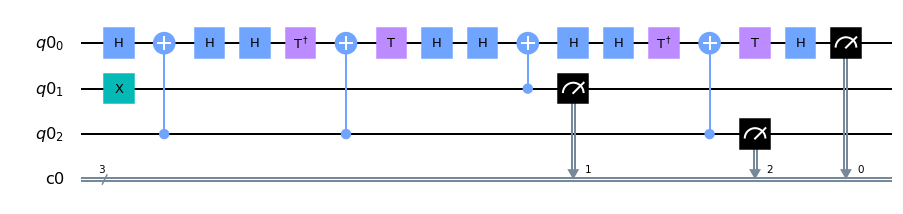

In [9]:
testZ.draw(output='mpl')

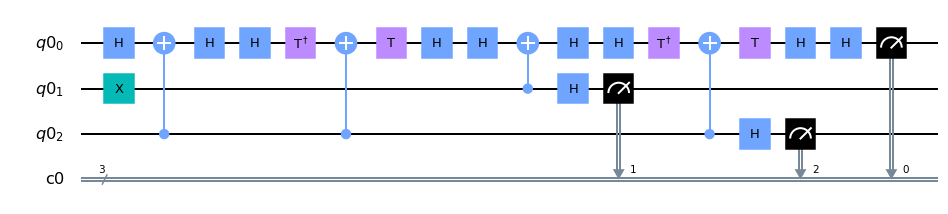

In [10]:
testX.draw(output='mpl')

### Run the algorithm

# Run on IBM cloud simulator (requires account setup above)
# from qiskit_ibm_runtime import SamplerV2 as Sampler
# service = QiskitRuntimeService(channel='ibm_quantum')
# backend_cloud = service.backend('ibmq_qasm_simulator')
# job = Sampler(backend_cloud).run([transpile(testZ, backend_cloud),
#                                   transpile(testX, backend_cloud)], shots=1024)
# result = job.result()
backend = AerSimulator()
result = backend.run(transpile([testZ, testX], backend), shots=1024).result()

In [18]:
# Run on local AerSimulator (was: ibmq_qasm_simulator)
backend = AerSimulator()
result = backend.run(transpile([testZ, testX], backend), shots=1024).result()

from qiskit.visualization import plot_histogram
plot_histogram(result.get_counts(testZ)) 


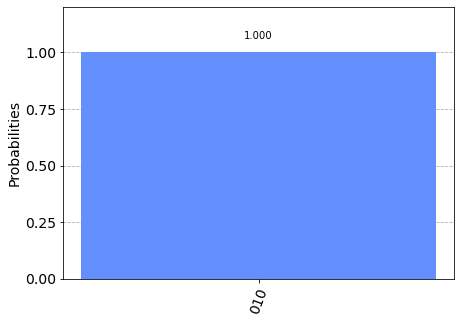

In [19]:
from qiskit.visualization import plot_histogram
plot_histogram(result.get_counts(testZ))

<span style="color:blue"> **As the initial state is 010 it should not change by CCNOT. </br>
    As we see simulator gives the correct result** </span>

backend = AerSimulator()

result = backend.run(transpile([testZ, testX], backend), shots=1024).result()

In [16]:
# Local AerSimulator
backend = AerSimulator()
result = backend.run(transpile([testZ, testX], backend), shots=1024).result()

from qiskit.visualization import plot_histogram
plot_histogram(result.get_counts(testZ)) 


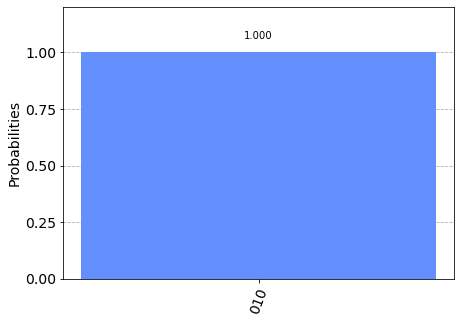

In [17]:
from qiskit.visualization import plot_histogram
plot_histogram(result.get_counts(testZ))

#### 3) Find less buisy device

In [ ]:
# Find least busy real device (requires IBM Quantum account)
# service = QiskitRuntimeService(channel='ibm_quantum')
# small_devices = service.backends(filters=lambda x: x.configuration().n_qubits == 5
#                                   and not x.configuration().simulator)
# backend_real = service.least_busy(operational=True, simulator=False, min_num_qubits=5)

#### 3a) Choose backend: least buisy

In [ ]:
# Run on least busy real device (requires IBM Quantum account)
# from qiskit_ibm_runtime import SamplerV2 as Sampler
# service = QiskitRuntimeService(channel='ibm_quantum')
# backend_real = service.least_busy(operational=True, simulator=False, min_num_qubits=3)
# sampler = Sampler(backend_real)
# job = sampler.run([transpile(testZ, backend_real), transpile(testX, backend_real)], shots=1024)
# result = job.result()
backend = AerSimulator()
result = backend.run(transpile([testZ, testX], backend), shots=1024).result()

Plot results as histogram

In [ ]:
from qiskit.visualization import plot_histogram
plot_histogram(result.get_counts(testZ)) 

#### As the initial state is 010 it should not change by CCNOT. 
####    As we see real experiment gives this result with probability 0.854

### Let's try another input state, e.g. 011

In [30]:
qr=qk.QuantumRegister(3)
cr=qk.ClassicalRegister(3)
qc=qk.QuantumCircuit(qr,cr)

qc.x(qr[2])
qc.x(qr[1])

# A gate
qc.h(qr[0])
qc.cx(qr[2],qr[0])
qc.h(qr[0])

# B gate
qc.h(qr[0])
qc.tdg(qr[0])
qc.cx(qr[2],qr[0])
qc.t(qr[0])
qc.h(qr[0])

# A gate
qc.h(qr[0])
qc.cx(qr[1],qr[0])
qc.h(qr[0])

# B gate
qc.h(qr[0])
qc.tdg(qr[0])
qc.cx(qr[2],qr[0])
qc.t(qr[0])
qc.h(qr[0])

measureZ=qk.QuantumCircuit(qr,cr)
measureZ.measure(qr,cr)
testZ=qc+measureZ


#### Choose backend: Local qiskit simulator 

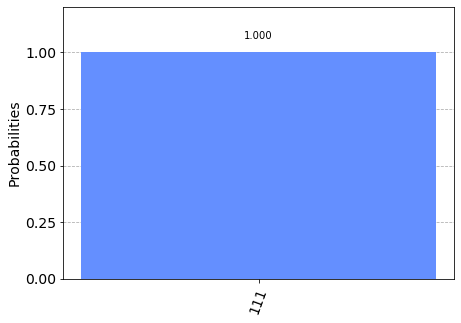

In [32]:
backend = AerSimulator()
result = backend.run(transpile([testZ], backend), shots=1024).result()
from qiskit.visualization import plot_histogram
plot_histogram(result.get_counts(testZ))

backend = AerSimulator()

result = backend.run(transpile([testZ], backend), shots=1024).result()
from qiskit.visualization import plot_histogram
plot_histogram(result.get_counts(testZ)) 

In [33]:
# Run on real IBM device (requires account setup):
# from qiskit_ibm_runtime import SamplerV2 as Sampler
# service = QiskitRuntimeService(channel='ibm_quantum')
# backend_real = service.least_busy(operational=True, simulator=False, min_num_qubits=3)
# sampler = Sampler(backend_real)
# job = sampler.run([transpile(testZ, backend_real)], shots=1024)
# result_counts = job.result()[0].data.c.get_counts()
# Using simulator as stand-in:
result_counts = result.get_counts(testZ)
print('(Using simulator results. Uncomment above for real hardware.)')

In [ ]:
# Run on real IBM device (requires account setup)
# from qiskit_ibm_runtime import SamplerV2 as Sampler
# service = QiskitRuntimeService(channel='ibm_quantum')
# backend_real = service.least_busy(operational=True, simulator=False, min_num_qubits=3)
# sampler = Sampler(backend_real)
# job = sampler.run([transpile(testZ, backend_real)], shots=1024)
# result = job.result()

In [ ]:
from qiskit.visualization import plot_histogram
plot_histogram(result.get_counts(testZ)) 

In [ ]:
# --- IBM Quantum hardware setup (run once) ---
# from qiskit_ibm_runtime import QiskitRuntimeService
# QiskitRuntimeService.save_account(channel='ibm_quantum', token='YOUR_TOKEN', overwrite=True)
# service = QiskitRuntimeService(channel='ibm_quantum')
# backend = service.backend('ibmq_armonk')

In [28]:
dt = backend_config.dt
print(f"Sampling time: {dt*1e9} ns") 

Sampling time: 0.2222222222222222 ns


In [29]:
backend_defaults = backend.defaults()